In [20]:
from pathlib import Path
import pandas as pd

def get_project_root():
    return Path().resolve().parent

index = pd.read_csv(get_project_root() / "data" / "processed" / "wide_validation_index.csv")
map24 = pd.read_csv(get_project_root() / "data" / "mapping" / "master_2024.csv")

In [21]:
map24.head()

,nama_prov,value_prov,variable_kab,nama_kab,value_kab,kab,fullname
0,ACEH,11,R102,SIMEULUE,1101,1,ACEH SIMEULUE
1,ACEH,11,R102,ACEH SINGKIL,1102,2,ACEH ACEH SINGKIL
2,ACEH,11,R102,ACEH SELATAN,1103,3,ACEH ACEH SELATAN
3,ACEH,11,R102,ACEH TENGGARA,1104,4,ACEH ACEH TENGGARA
4,ACEH,11,R102,ACEH TIMUR,1105,5,ACEH ACEH TIMUR


In [22]:
index24 = index[['fullname','year','vaw_reported_cases','value_kab']].dropna()

# left merge map24[['value_kab', 'value_prov']]
index24 = index24.merge(
    map24[['value_kab', 'value_prov', 'nama_prov']],
    on='value_kab',
    how='left'
)

index24

,fullname,year,vaw_reported_cases,value_kab,value_prov,nama_prov
0,ACEH ACEH BARAT,2017,7.0,1107,11,ACEH
1,ACEH ACEH BARAT,2018,11.0,1107,11,ACEH
2,ACEH ACEH BARAT,2019,13.0,1107,11,ACEH
3,ACEH ACEH BARAT,2020,11.0,1107,11,ACEH
4,ACEH ACEH BARAT,2021,19.0,1107,11,ACEH
...,...,...,...,...,...,...
4576,SUMATERA UTARA TOBA,2021,2.0,1206,12,SUMATERA UTARA
4577,SUMATERA UTARA TOBA,2022,1.0,1206,12,SUMATERA UTARA
4578,SUMATERA UTARA TOBA,2023,7.0,1206,12,SUMATERA UTARA
4579,SUMATERA UTARA TOBA,2024,3.0,1206,12,SUMATERA UTARA


In [23]:
output_path = get_project_root().parent / "all_cases_long.csv"
index24.to_csv(output_path, index=False)

In [24]:
prov_cases = (
    index24
    .groupby(['value_prov', 'nama_prov', 'year'], as_index=False)['vaw_reported_cases']
    .sum()
)

In [25]:
output_path = get_project_root().parent / "prov_cases_long.csv"
prov_cases.to_csv(output_path, index=False)

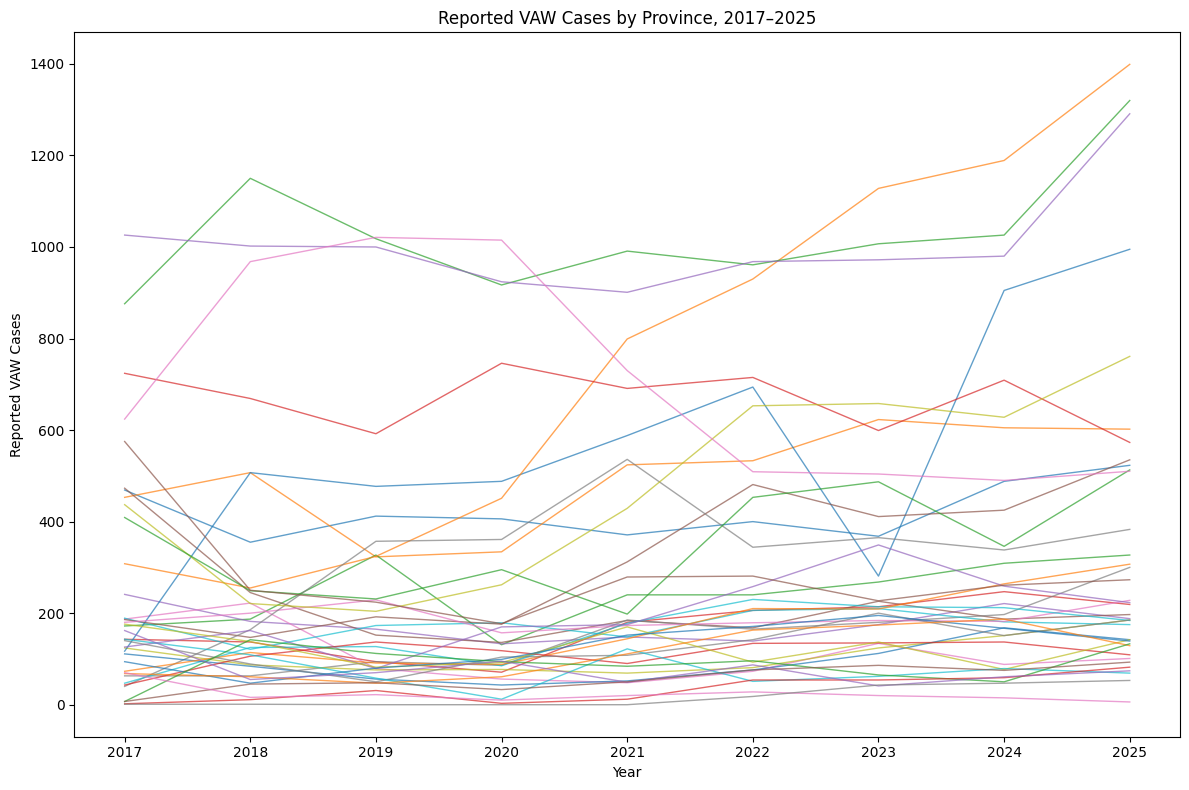

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

for prov, group in prov_cases.groupby('value_prov'):
    group = group.sort_values('year')
    ax.plot(
        group['year'],
        group['vaw_reported_cases'],
        linewidth=1,
        alpha=0.7
    )

ax.set_xlabel('Year')
ax.set_ylabel('Reported VAW Cases')
ax.set_title('Reported VAW Cases by Province, 2017–2025')

plt.tight_layout()
plt.show()